<a href="https://colab.research.google.com/github/RenanSluder/templateFiapVfinal/blob/main/C%C3%B3pia_de_RenanRamos_RM573201_pbl_fase5_web_colab_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FarmTech Solutions — Machine Learning na Cabeça
## Fase 5 — Capítulo 1 — Rendimento de Safra: Clusterização e Regressão Supervisionada
### 🌐 Versão Google Colab (self-contained, roda sem clonar o repositório)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RenanSluder/FIAP-GRAD-ON-IA/blob/main/ANO1/FASE5/cap1/src/RenanRamos_RM573201_pbl_fase5_web-colab.ipynb)

**Aluno:** Renan Ramos
**RM:** RM573201
**Turma:** B — Inteligência Artificial

---

### ℹ️ Sobre esta versão

Este notebook é a **versão Web/Google Colab** do trabalho. Ele é **totalmente autocontido**:

- Não depende de clonar o repositório nem da pasta `src/` do projeto — todas as funções de processamento, clusterização e modelagem estão definidas diretamente aqui, nas células abaixo.
- O dataset é carregado automaticamente a partir do GitHub do projeto; caso o arquivo não esteja acessível (ex: repositório privado, sem internet), o notebook **gera automaticamente** um dataset sintético equivalente, então a execução nunca falha por falta do arquivo.
- Os gráficos são salvos numa pasta local do ambiente do Colab (`/content/entregas/graficos`), e também exibidos inline em cada célula.

> Para a versão local (que reaproveita os módulos testados em `src/data_processing.py`, `src/clustering.py` e `src/regression_models.py`, cobertos por `tests/`), use o notebook irmão: `src/RenanRamos_RM573201_pbl_fase5.ipynb`.

### Objetivo

A FarmTech Solutions presta serviços de IA para uma fazenda de médio porte (~200 hectares) que produz várias culturas. Este notebook:

1. Faz uma **análise exploratória** da base `crop_yield.csv` para entender as variáveis climáticas e o rendimento de safra;
2. Aplica **clusterização** (aprendizado não supervisionado) para encontrar tendências de rendimento e identificar outliers;
3. Desenvolve **cinco modelos preditivos** (algoritmos diferentes) de regressão supervisionada para prever o rendimento (`Yield`), avaliando cada um com métricas pertinentes ao problema (MAE, MSE, RMSE, R²).

### Base de dados

| Coluna | Descrição |
|---|---|
| `Crop` | Nome da safra para a qual o rendimento está sendo medido |
| `Precipitation (mm day)` | Quantidade de chuva em milímetros por dia |
| `Specific Humidity at 2 Meters (g/kg)` | Vapor de água no ar por kg de ar seco, a 2m de altura |
| `Relative Humidity at 2 Meters (%)` | Vapor de água no ar como % da quantidade máxima possível a dada temperatura/pressão |
| `Temperature at 2 Meters (C)` | Temperatura em °C a 2m de altura |
| `Yield` | Rendimento em toneladas por hectare |


---
# 1. Instalação de Dependências e Importações

O Google Colab já vem com `pandas`, `numpy`, `scikit-learn`, `matplotlib` e `seaborn` pré-instalados. A célula abaixo garante a versão mínima necessária mesmo assim, de forma idempotente (não reinstala se já estiver satisfeita).

In [ ]:
# Garantir dependências (idempotente — no Colab, normalmente já estão instaladas)
%pip install -q "pandas>=1.3.0" "numpy>=1.20.0" "scikit-learn>=1.0.0" "matplotlib>=3.3.0" "seaborn>=0.11.0"


In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Pasta de saída dos gráficos (dentro do ambiente do Colab, sem depender de '..')
GRAFICOS_DIR = 'entregas/graficos'
os.makedirs(GRAFICOS_DIR, exist_ok=True)

print('Todas as importações realizadas com sucesso!')
print(f'Random state usado no projeto: {RANDOM_STATE}')
print(f'Gráficos serão salvos em: {os.path.abspath(GRAFICOS_DIR)}')


Todas as importações realizadas com sucesso!
Random state usado no projeto: 42
Gráficos serão salvos em: /content/entregas/graficos


Todas as importações realizadas com sucesso!
Random state usado no projeto: 42
Gráficos serão salvos em: /home/rrmo/projects/fiap/FIAP-GRAD-ON-IA/ANO1/FASE5/cap1/src/entregas/graficos

---
# 2. Funções de Processamento, Clusterização e Modelagem

Esta seção reproduz, em células de código autocontidas, o mesmo conteúdo dos módulos `src/data_processing.py`, `src/clustering.py` e `src/regression_models.py` da versão local do projeto — assim o notebook roda no Colab sem precisar clonar o repositório inteiro.

## 2.1 Processamento de Dados

In [ ]:
NUMERIC_COLUMNS = [
    'Precipitation (mm day)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)',
]
TARGET_COLUMN = 'Yield'
CATEGORICAL_COLUMN = 'Crop'


def detectar_outliers_iqr(df, coluna, k=1.5):
    """Detecta outliers em uma coluna numérica usando o método IQR (Tukey)"""
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - k * iqr
    limite_superior = q3 + k * iqr
    return (df[coluna] < limite_inferior) | (df[coluna] > limite_superior)


def resumo_outliers(df, colunas=None):
    """Resumo da quantidade/percentual de outliers (IQR) por coluna"""
    colunas = colunas or [*NUMERIC_COLUMNS, TARGET_COLUMN]
    registros = []
    for coluna in colunas:
        mascara = detectar_outliers_iqr(df, coluna)
        registros.append({
            'coluna': coluna,
            'total_outliers': int(mascara.sum()),
            'percentual_outliers': round(100 * mascara.mean(), 2),
        })
    return pd.DataFrame(registros)


def preparar_features_target(df, one_hot_crop=True):
    """Separa features (X) e alvo (y), com one-hot encoding opcional em Crop"""
    y = df[TARGET_COLUMN].copy()
    if one_hot_crop:
        X = pd.get_dummies(df.drop(columns=[TARGET_COLUMN]), columns=[CATEGORICAL_COLUMN])
    else:
        X = df[NUMERIC_COLUMNS].copy()
    return X, y


def matriz_correlacao_numerica(df):
    """Matriz de correlação de Pearson das colunas numéricas + alvo"""
    colunas = [*NUMERIC_COLUMNS, TARGET_COLUMN]
    return df[colunas].corr()

print('Funções de processamento de dados definidas.')


Funções de processamento de dados definidas.


## 2.2 Clusterização

In [ ]:
def escalonar_features(df, colunas):
    """Padroniza (z-score) as colunas informadas"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[colunas])
    return X_scaled, scaler


def encontrar_k_ideal(X_scaled, k_min=2, k_max=10, random_state=RANDOM_STATE):
    """Testa valores de k via inércia (cotovelo) e coeficiente de silhueta"""
    resultados = []
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        silhouette = silhouette_score(X_scaled, labels) if k > 1 else np.nan
        resultados.append({'k': k, 'inertia': kmeans.inertia_, 'silhouette_score': silhouette})
    return pd.DataFrame(resultados)


def clusterizar(X_scaled, n_clusters, random_state=RANDOM_STATE):
    """Aplica o KMeans com o número de clusters definido"""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    return labels, kmeans


def perfil_por_cluster(df, labels, colunas):
    """Perfil médio de cada cluster + contagem de observações"""
    df_com_cluster = df.copy()
    df_com_cluster['cluster'] = labels
    perfil = df_com_cluster.groupby('cluster')[colunas].mean()
    perfil['total_observacoes'] = df_com_cluster.groupby('cluster').size()
    return perfil.reset_index()

print('Funções de clusterização definidas.')


Funções de clusterização definidas.


## 2.3 Modelagem Preditiva (Regressão Supervisionada)

In [ ]:
def dividir_treino_teste(X, y, test_size=0.2, random_state=RANDOM_STATE):
    """Divide os dados em treino (80%) e teste (20%) por padrão"""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def escalonar_treino_teste(X_train, X_test):
    """Ajusta o StandardScaler no treino e aplica em treino e teste"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


def construir_modelos(random_state=RANDOM_STATE):
    """Os 5 modelos de regressão (algoritmos distintos) exigidos pela atividade"""
    return {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0, random_state=random_state),
        'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=random_state),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=random_state),
        'Support Vector Regression': SVR(kernel='rbf', C=10, epsilon=0.1),
    }


def avaliar_modelo(y_true, y_pred):
    """Métricas de avaliação de regressão: MAE, MSE, RMSE e R²"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


def treinar_e_avaliar_todos(modelos, X_train, X_test, y_train, y_test):
    """Treina cada modelo e avalia no teste, retorna tabela ordenada por R²"""
    linhas = []
    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        metricas = avaliar_modelo(y_test.values, y_pred)
        linhas.append({'Modelo': nome, **metricas})
    return pd.DataFrame(linhas).sort_values('R2', ascending=False).reset_index(drop=True)

print('Funções de modelagem preditiva definidas.')


Funções de modelagem preditiva definidas.


---
# 3. Carregamento do Dataset

Esta célula tenta, nesta ordem:

1. Ler `crop_yield.csv` a partir da **URL raw do GitHub** do projeto (funciona em qualquer navegador, sem precisar montar o Google Drive nem fazer upload manual);
2. Se o download falhar (ex: sem internet, repositório indisponível), **gera automaticamente** um dataset sintético equivalente, com a mesma metodologia usada para criar o arquivo original do projeto (culturas com faixas climáticas plausíveis, relação causal entre clima e rendimento, outliers propositais).

> **Nota:** a base real desta atividade é disponibilizada apenas no portal da FIAP. O dataset usado aqui (seja via GitHub ou gerado localmente) é **sintético**, preservando as mesmas colunas e uma relação causal plausível entre clima e rendimento — suficiente para demonstrar o pipeline completo de ponta a ponta.

In [ ]:
CROP_YIELD_URL = (
    'https://raw.githubusercontent.com/RenanSluder/FIAP-GRAD-ON-IA/'
    'main/ANO1/FASE5/cap1/data/crop_yield.csv'
)


def gerar_dataset_sintetico(seed=RANDOM_STATE, n_por_cultura=220):
    """
    Gera um dataset sintético de rendimento de safra, com a mesma metodologia
    usada para criar o crop_yield.csv original do projeto: cada cultura tem uma
    faixa climática plausível, o rendimento reage a estresse hídrico/térmico,
    e uma pequena fração de outliers é injetada propositalmente.
    """
    rng = np.random.RandomState(seed)

    culturas = {
        'Cotton':    {'precip': (60, 180),  'sh': (12, 18), 'rh': (35, 65), 'temp': (22, 34), 'yield_base': (1.2, 2.8)},
        'Rice':      {'precip': (150, 320), 'sh': (16, 22), 'rh': (65, 90), 'temp': (20, 32), 'yield_base': (3.0, 6.5)},
        'Wheat':     {'precip': (40, 110),  'sh': (6, 12),  'rh': (35, 60), 'temp': (10, 24), 'yield_base': (2.0, 4.5)},
        'Maize':     {'precip': (70, 160),  'sh': (10, 16), 'rh': (45, 70), 'temp': (18, 30), 'yield_base': (3.5, 7.5)},
        'Soybean':   {'precip': (80, 200),  'sh': (11, 17), 'rh': (50, 75), 'temp': (18, 30), 'yield_base': (2.0, 4.2)},
        'Barley':    {'precip': (35, 100),  'sh': (5, 11),  'rh': (30, 55), 'temp': (8, 22),  'yield_base': (1.8, 3.8)},
        'Sugarcane': {'precip': (100, 280), 'sh': (14, 20), 'rh': (60, 85), 'temp': (22, 34), 'yield_base': (55, 95)},
    }

    rows = []
    for cultura, p in culturas.items():
        for _ in range(n_por_cultura):
            precip = rng.uniform(*p['precip'])
            sh = rng.uniform(*p['sh'])
            rh = rng.uniform(*p['rh'])
            temp = rng.uniform(*p['temp'])

            base_low, base_high = p['yield_base']
            base = rng.uniform(base_low, base_high)

            precip_mid = sum(p['precip']) / 2
            temp_mid = sum(p['temp']) / 2
            precip_range = (p['precip'][1] - p['precip'][0]) / 2
            temp_range = (p['temp'][1] - p['temp'][0]) / 2

            stress_precip = 1 - 0.25 * (abs(precip - precip_mid) / precip_range)
            stress_temp = 1 - 0.20 * (abs(temp - temp_mid) / temp_range)
            umidade_bonus = 1 + 0.05 * ((rh - 50) / 50)

            rendimento = base * stress_precip * stress_temp * umidade_bonus
            rendimento += rng.normal(0, base * 0.05)
            rendimento = max(rendimento, 0.1)

            rows.append({
                CATEGORICAL_COLUMN: cultura,
                'Precipitation (mm day)': round(precip, 2),
                'Specific Humidity at 2 Meters (g/kg)': round(sh, 2),
                'Relative Humidity at 2 Meters (%)': round(rh, 2),
                'Temperature at 2 Meters (C)': round(temp, 2),
                TARGET_COLUMN: round(rendimento, 3),
            })

    df_sintetico = pd.DataFrame(rows)

    # Outliers propositais (~1.5% das linhas)
    n_outliers = int(len(df_sintetico) * 0.015)
    outlier_idx = rng.choice(df_sintetico.index, size=n_outliers, replace=False)
    for idx in outlier_idx:
        if rng.rand() < 0.5:
            df_sintetico.loc[idx, TARGET_COLUMN] *= rng.uniform(2.5, 3.5)
        else:
            df_sintetico.loc[idx, 'Precipitation (mm day)'] *= rng.uniform(2.5, 4.0)

    return df_sintetico.sample(frac=1, random_state=seed).reset_index(drop=True)


try:
    df = pd.read_csv(CROP_YIELD_URL)
    esperadas = {CATEGORICAL_COLUMN, TARGET_COLUMN, *NUMERIC_COLUMNS}
    if esperadas - set(df.columns):
        raise ValueError('Colunas inesperadas no CSV remoto')
    print(f'Dataset carregado com sucesso a partir do GitHub: {CROP_YIELD_URL}')
except Exception as erro:
    print(f'Não foi possível carregar o CSV do GitHub ({erro!r}).')
    print('Gerando dataset sintético localmente como fallback...')
    df = gerar_dataset_sintetico()
    print('Dataset sintético gerado com sucesso (mesma metodologia do dataset original).')

print(f'\nForma do dataset: {df.shape}')
df.head()


Não foi possível carregar o CSV do GitHub (<HTTPError 404: 'Not Found'>).
Gerando dataset sintético localmente como fallback...
Dataset sintético gerado com sucesso (mesma metodologia do dataset original).

Forma do dataset: (1540, 6)


,Crop,Precipitation (mm day),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,Cotton,152.19,14.51,47.64,30.85,1.213
1,Barley,94.25,7.07,45.54,8.54,1.495
2,Cotton,71.17,17.38,62.01,29.60,1.443
3,Cotton,120.90,12.04,43.61,29.40,2.669
4,Soybean,82.54,13.51,69.40,22.06,2.199


---
# 4. Exploração Inicial dos Dados

## 4.1 Tipos de Dados, Valores Ausentes e Duplicatas

In [ ]:
print('--- Tipos de dados ---')
print(df.dtypes)

print('\n--- Valores ausentes ---')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal de valores ausentes: {missing.sum()}')

print('\n--- Duplicatas ---')
print(f'Total de linhas duplicadas: {df.duplicated().sum()}')


--- Tipos de dados ---
Crop                                     object
Precipitation (mm day)                  float64
Specific Humidity at 2 Meters (g/kg)    float64
Relative Humidity at 2 Meters (%)       float64
Temperature at 2 Meters (C)             float64
Yield                                   float64
dtype: object

--- Valores ausentes ---
Crop                                    0
Precipitation (mm day)                  0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Total de valores ausentes: 0

--- Duplicatas ---
Total de linhas duplicadas: 0


## 4.2 Estatísticas Descritivas

In [ ]:
df[NUMERIC_COLUMNS + [TARGET_COLUMN]].describe().round(2)


,Precipitation (mm day),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,1540.00,1540.00,1540.00,1540.00,1540.00
mean,136.75,13.51,58.74,23.05,11.25
std,72.96,4.10,14.18,6.04,21.18
min,35.08,5.00,30.02,8.01,0.81
25%,82.87,10.48,47.71,19.30,1.99
50%,122.94,13.88,57.58,23.56,2.83
75%,174.36,16.63,69.17,27.78,4.56
max,852.11,21.96,89.62,33.98,139.55


## 4.3 Distribuição por Cultura

In [ ]:
crop_counts = df[CATEGORICAL_COLUMN].value_counts()
print(crop_counts)
print(f'\nTotal de culturas diferentes: {df[CATEGORICAL_COLUMN].nunique()}')


Crop
Cotton       220
Barley       220
Soybean      220
Sugarcane    220
Maize        220
Wheat        220
Rice         220
Name: count, dtype: int64

Total de culturas diferentes: 7


---
# 5. Análise Exploratória de Dados (EDA) com Visualizações

## 5.1 Gráfico 1 — Distribuição de Culturas e Rendimento Médio

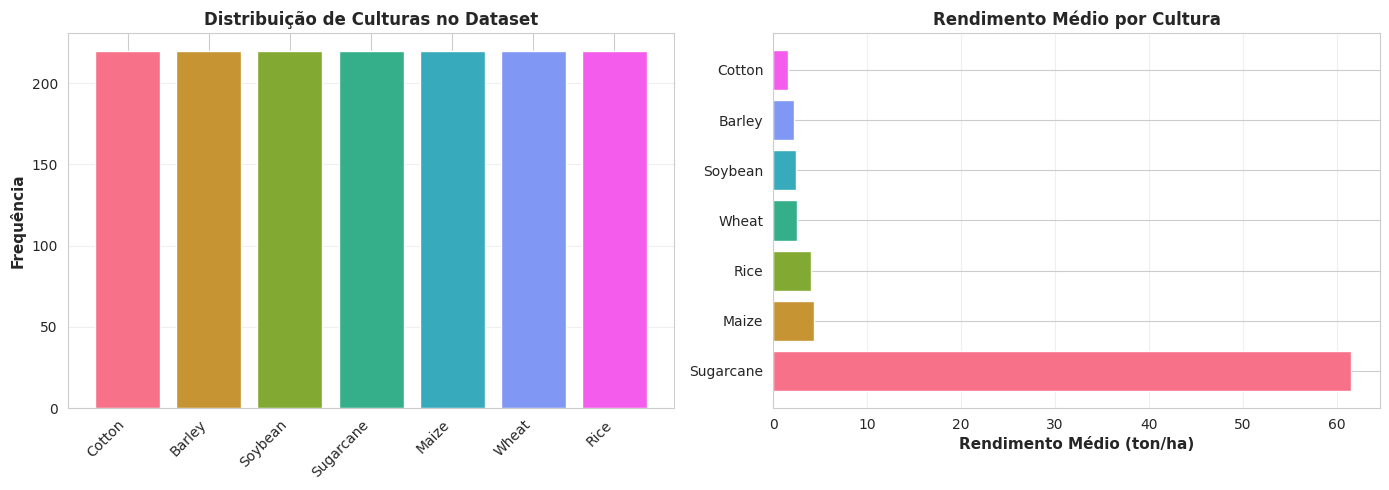

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('husl', len(crop_counts))

ax1.bar(range(len(crop_counts)), crop_counts.values, color=colors)
ax1.set_xticks(range(len(crop_counts)))
ax1.set_xticklabels(crop_counts.index, rotation=45, ha='right')
ax1.set_ylabel('Frequência', fontsize=11, fontweight='bold')
ax1.set_title('Distribuição de Culturas no Dataset', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

rendimento_medio = df.groupby(CATEGORICAL_COLUMN)[TARGET_COLUMN].mean().sort_values(ascending=False)
ax2.barh(rendimento_medio.index, rendimento_medio.values, color=colors)
ax2.set_xlabel('Rendimento Médio (ton/ha)', fontsize=11, fontweight='bold')
ax2.set_title('Rendimento Médio por Cultura', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/01_distribuicao_e_rendimento.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.2 Gráfico 2 — Matriz de Correlação

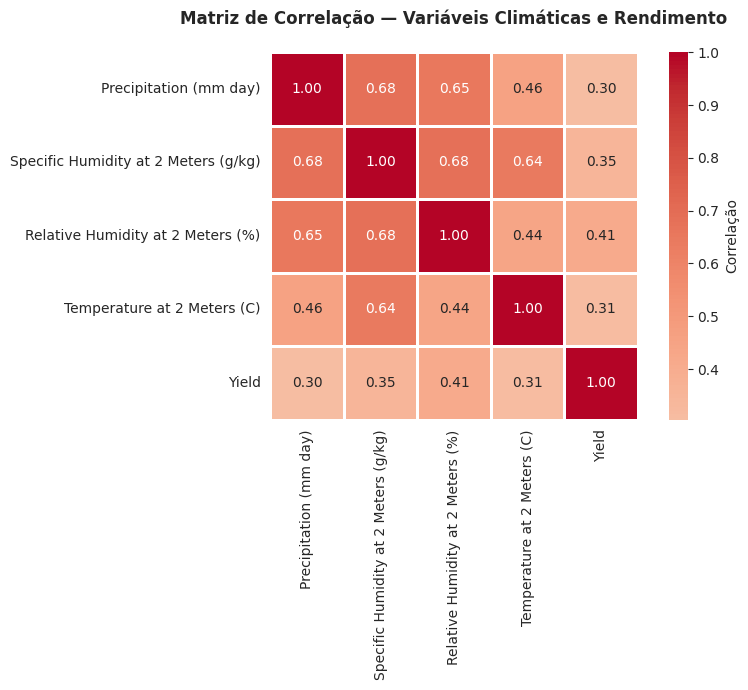

In [ ]:
corr = matriz_correlacao_numerica(df)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlação'})
plt.title('Matriz de Correlação — Variáveis Climáticas e Rendimento', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/02_matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.3 Gráfico 3 — Distribuição das Variáveis Contínuas

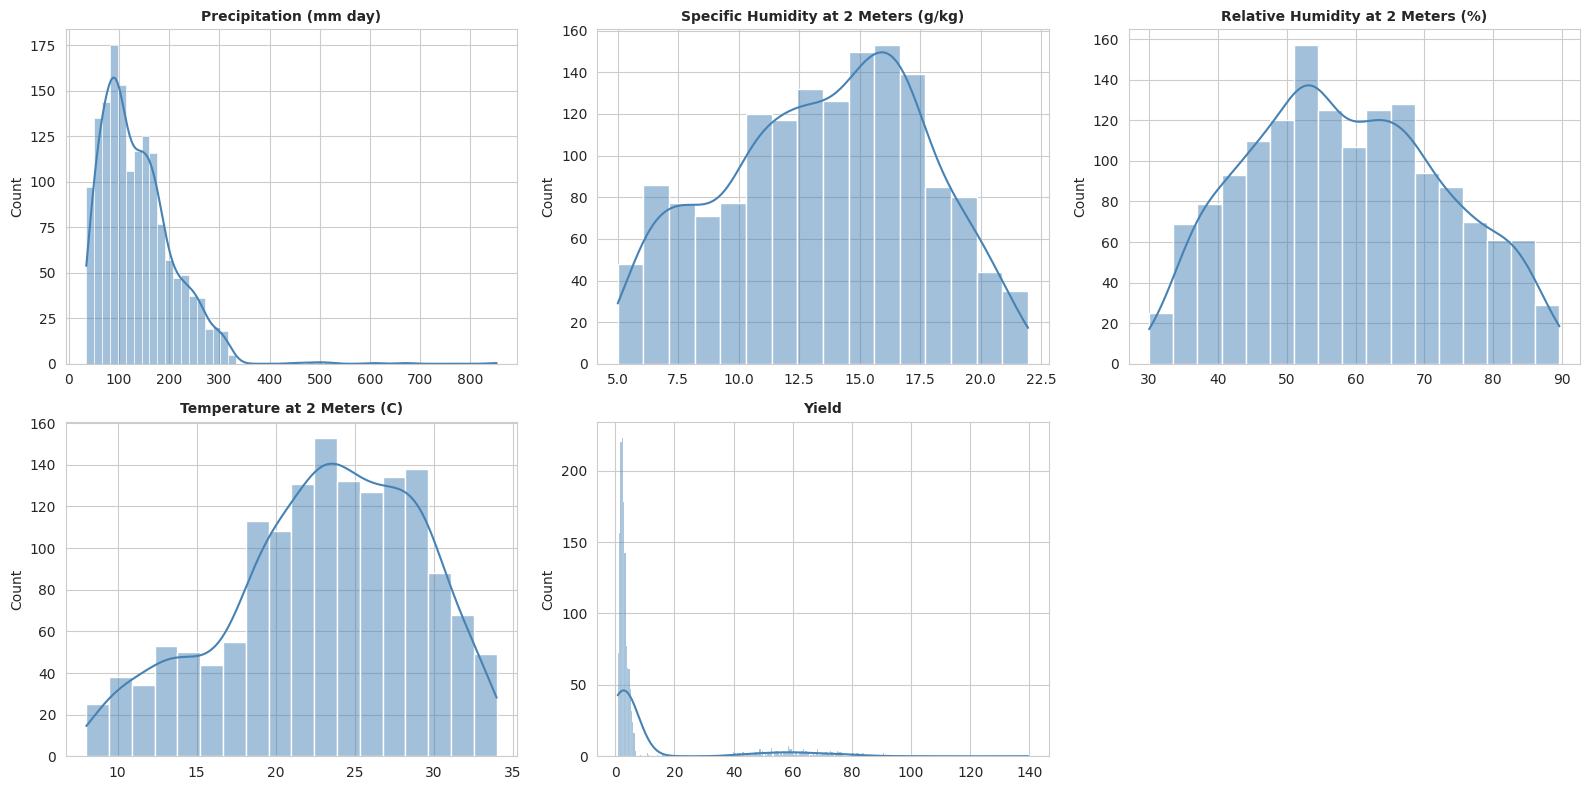

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colunas_dist = NUMERIC_COLUMNS + [TARGET_COLUMN]

for ax, col in zip(axes.flat, colunas_dist):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

if len(colunas_dist) < len(axes.flat):
    for ax in list(axes.flat)[len(colunas_dist):]:
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/03_distribuicao_variaveis.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.4 Gráfico 4 — Boxplot de Rendimento por Cultura

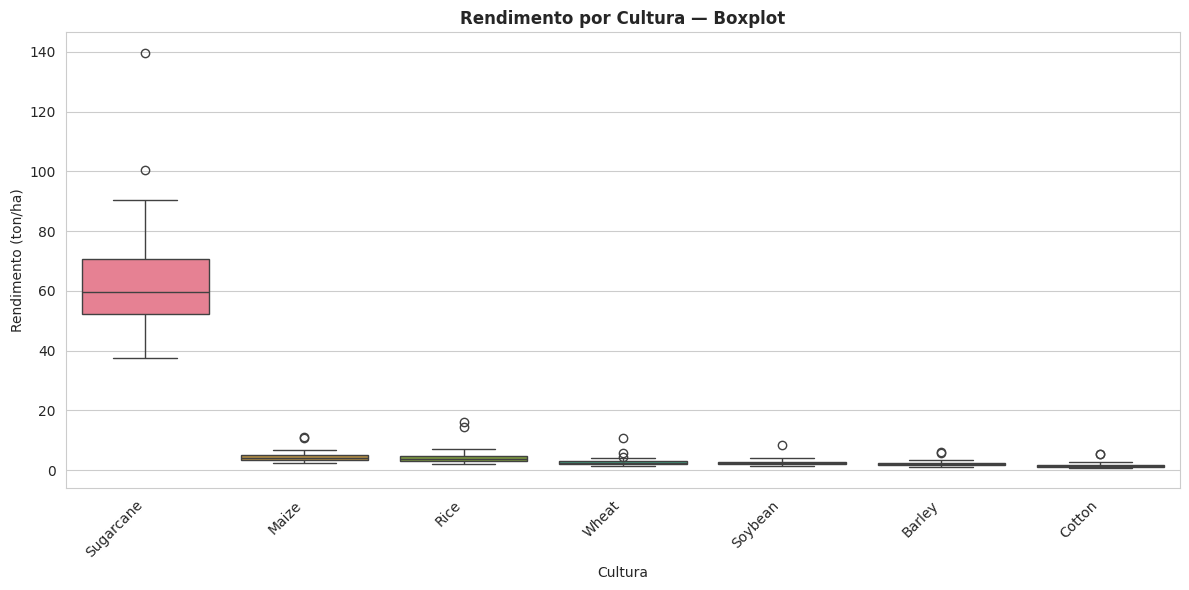

In [ ]:
plt.figure(figsize=(12, 6))
ordem_culturas = df.groupby(CATEGORICAL_COLUMN)[TARGET_COLUMN].median().sort_values(ascending=False).index
sns.boxplot(data=df, x=CATEGORICAL_COLUMN, y=TARGET_COLUMN, order=ordem_culturas, palette='husl')
plt.xticks(rotation=45, ha='right')
plt.title('Rendimento por Cultura — Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Cultura')
plt.ylabel('Rendimento (ton/ha)')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/04_boxplot_rendimento_cultura.png', dpi=300, bbox_inches='tight')
plt.show()


## 5.5 Gráfico 5 — Relação entre Clima e Rendimento (scatter matrix)

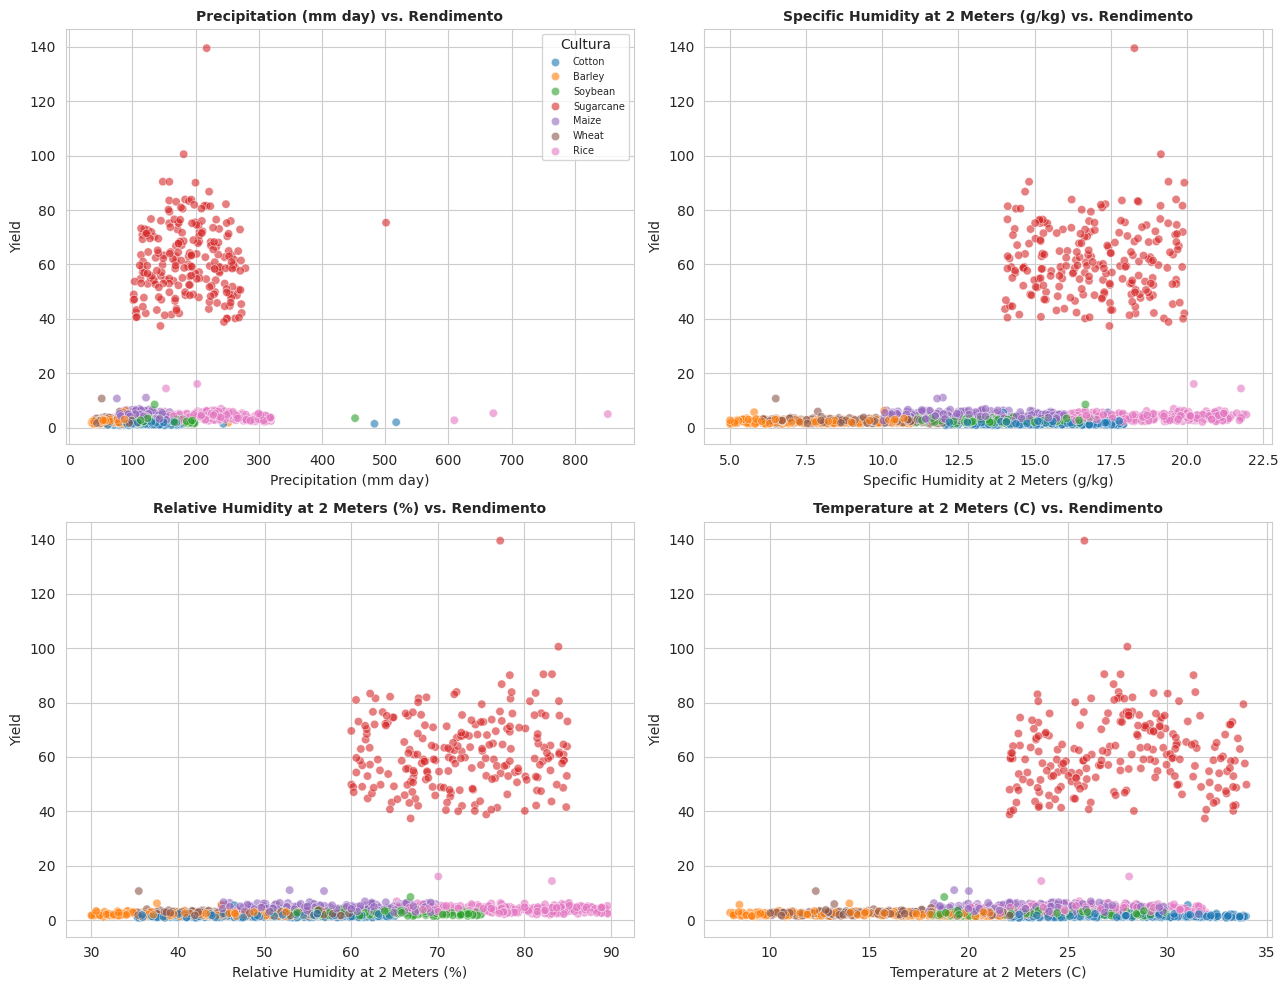

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.flat, NUMERIC_COLUMNS):
    sns.scatterplot(data=df, x=col, y=TARGET_COLUMN, hue=CATEGORICAL_COLUMN,
                     alpha=0.6, ax=ax, legend=(col == NUMERIC_COLUMNS[0]))
    ax.set_title(f'{col} vs. Rendimento', fontsize=10, fontweight='bold')

if axes.flat[0].get_legend() is not None:
    axes.flat[0].legend(loc='upper right', fontsize=7, title='Cultura')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/05_clima_vs_rendimento.png', dpi=300, bbox_inches='tight')
plt.show()


---
# 6. Detecção de Cenários Discrepantes (Outliers)

Usamos o método IQR (intervalo interquartil), critério clássico de Tukey: valores abaixo de `Q1 - 1.5*IQR` ou acima de `Q3 + 1.5*IQR` são considerados outliers.

In [ ]:
resumo = resumo_outliers(df)
resumo


,coluna,total_outliers,percentual_outliers
0,Precipitation (mm day),19,1.23
1,Specific Humidity at 2 Meters (g/kg),0,0.00
2,Relative Humidity at 2 Meters (%),0,0.00
3,Temperature at 2 Meters (C),0,0.00
4,Yield,226,14.68


In [ ]:
mascara_outliers_yield = detectar_outliers_iqr(df, TARGET_COLUMN)
outliers_yield = df[mascara_outliers_yield]

print(f'Total de outliers de Yield: {len(outliers_yield)} ({100*len(outliers_yield)/len(df):.2f}% do dataset)')
outliers_yield.sort_values(TARGET_COLUMN, ascending=False).head(10)


Total de outliers de Yield: 226 (14.68% do dataset)


,Crop,Precipitation (mm day),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
96,Sugarcane,217.30,18.28,77.20,25.83,139.553317
1510,Sugarcane,180.98,19.15,83.92,27.99,100.556000
76,Sugarcane,147.95,19.40,83.18,26.83,90.454000
569,Sugarcane,158.30,14.82,82.19,27.65,90.420000
1371,Sugarcane,199.67,19.92,78.31,31.32,90.081000
49,Sugarcane,221.23,14.69,77.37,27.30,86.782000
429,Sugarcane,183.24,19.65,72.16,27.55,83.902000
1336,Sugarcane,193.09,16.22,78.52,31.41,83.852000
609,Sugarcane,158.08,17.87,81.29,29.31,83.537000
1260,Sugarcane,189.25,18.39,62.19,30.02,83.322000


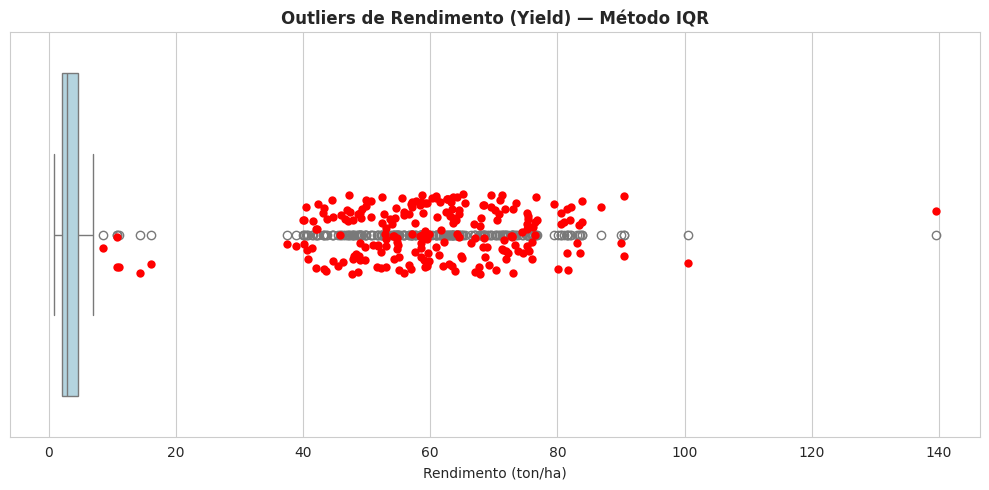

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df[TARGET_COLUMN], color='lightblue')
sns.stripplot(x=outliers_yield[TARGET_COLUMN], color='red', size=6, jitter=True)
plt.title('Outliers de Rendimento (Yield) — Método IQR', fontsize=12, fontweight='bold')
plt.xlabel('Rendimento (ton/ha)')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/06_outliers_yield.png', dpi=300, bbox_inches='tight')
plt.show()


---
# 7. Clusterização — Tendências de Rendimento (Aprendizado Não Supervisionado)

## 7.1 Escolha do Número de Clusters (Método do Cotovelo + Silhueta)

In [ ]:
colunas_cluster = NUMERIC_COLUMNS + [TARGET_COLUMN]
X_scaled, scaler_cluster = escalonar_features(df, colunas_cluster)

tabela_k = encontrar_k_ideal(X_scaled, k_min=2, k_max=10)
tabela_k


,k,inertia,silhouette_score
0,2,4509.263987,0.395402
1,3,3055.842960,0.371182
2,4,2137.726103,0.418358
3,5,1884.353575,0.348300
4,6,1734.054141,0.298600
5,7,1575.279556,0.304104
6,8,1499.919355,0.274905
7,9,1398.255141,0.265192
8,10,1327.648086,0.230416


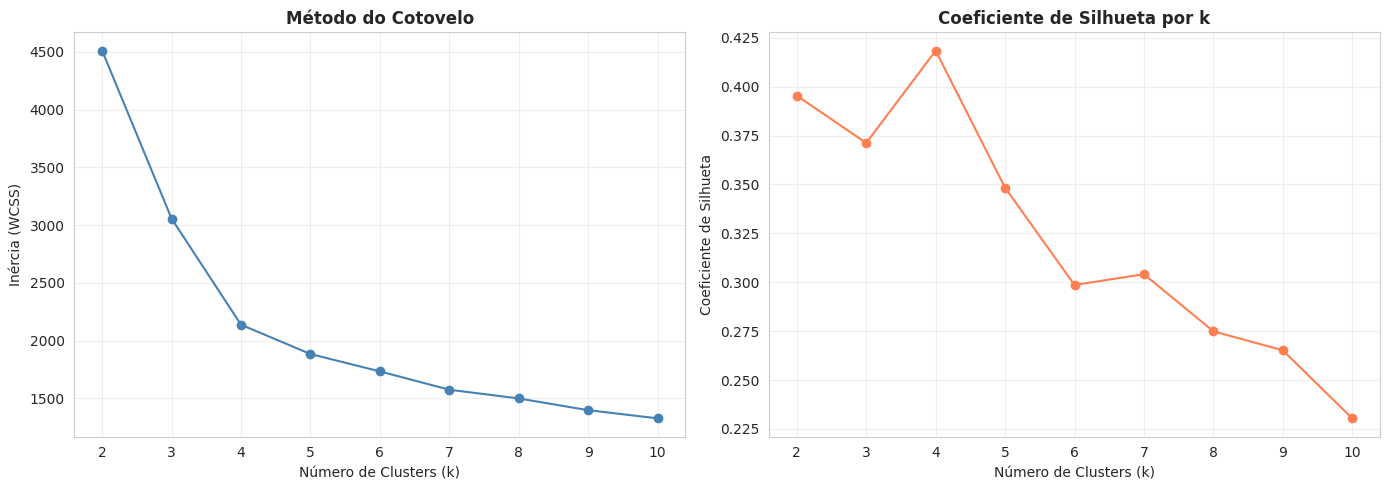

Melhor k pelo coeficiente de silhueta: 4


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tabela_k['k'], tabela_k['inertia'], marker='o', color='steelblue')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (WCSS)')
ax1.set_title('Método do Cotovelo', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(tabela_k['k'], tabela_k['silhouette_score'], marker='o', color='coral')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Coeficiente de Silhueta')
ax2.set_title('Coeficiente de Silhueta por k', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/07_escolha_k_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

k_escolhido = int(tabela_k.loc[tabela_k['silhouette_score'].idxmax(), 'k'])
print(f'Melhor k pelo coeficiente de silhueta: {k_escolhido}')


## 7.2 Aplicação do K-Means com o k Escolhido

In [ ]:
labels, modelo_kmeans = clusterizar(X_scaled, n_clusters=k_escolhido)
df['cluster'] = labels

print(f'Clusterização concluída com k={k_escolhido}')
print(df['cluster'].value_counts().sort_index())


Clusterização concluída com k=4
cluster
0    235
1    652
2    433
3    220
Name: count, dtype: int64


## 7.3 Perfil de Cada Cluster

In [ ]:
perfil = perfil_por_cluster(df, labels, colunas_cluster)
perfil.sort_values(TARGET_COLUMN, ascending=False)


,cluster,Precipitation (mm day),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,total_observacoes
3,3,189.776338,16.951500,72.616227,27.694682,61.512374,220
0,0,240.723279,18.652128,77.175447,25.745745,3.944079,235
1,1,125.992899,13.918405,56.489509,25.342301,2.793213,652
2,2,69.574681,8.366097,45.067644,15.774873,2.403523,433


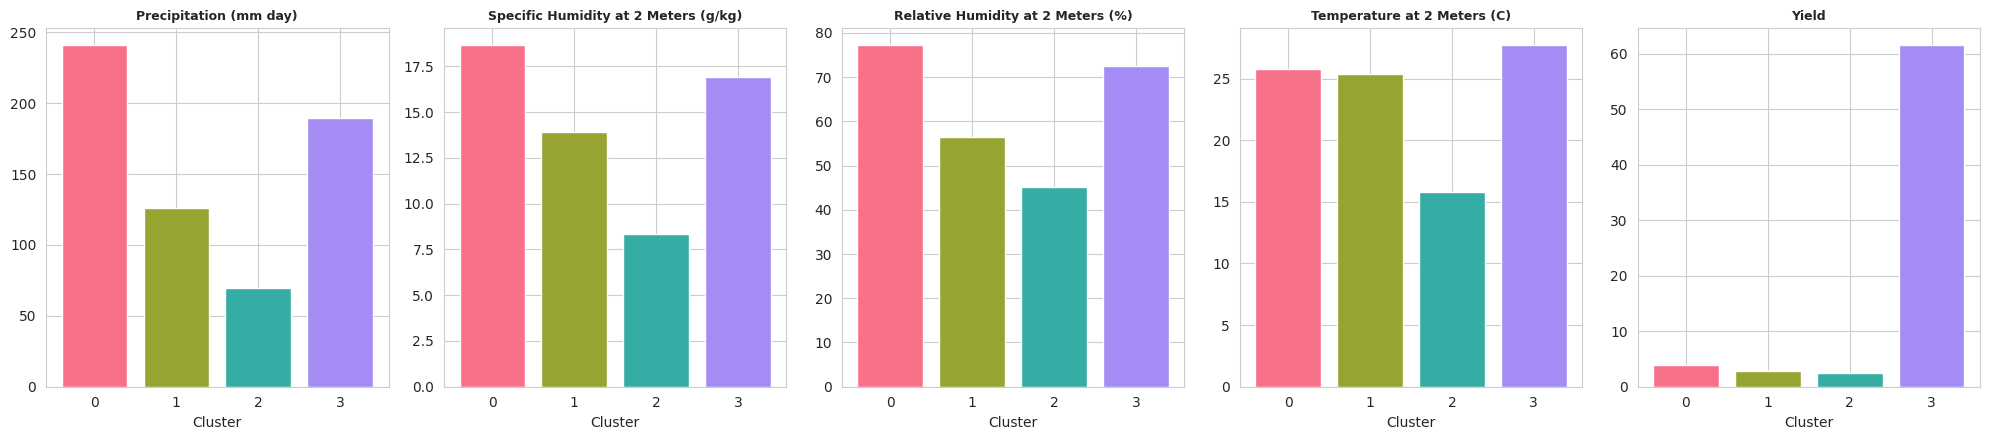

In [ ]:
fig, axes = plt.subplots(1, len(colunas_cluster), figsize=(4*len(colunas_cluster), 4.5))
for ax, col in zip(axes, colunas_cluster):
    cores_cluster = sns.color_palette('husl', len(perfil))
    ax.bar(perfil['cluster'].astype(str), perfil[col], color=cores_cluster)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/08_perfil_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
composicao = pd.crosstab(df['cluster'], df[CATEGORICAL_COLUMN])
composicao


Crop,Barley,Cotton,Maize,Rice,Soybean,Sugarcane,Wheat
cluster,,,,,,,
0,0,3,0,220,12,0,0
1,0,217,215,0,208,0,12
2,220,0,5,0,0,0,208
3,0,0,0,0,0,220,0


---
# 8. Preparação dos Dados para a Modelagem Preditiva

## 8.1 Separação de Features e Alvo (one-hot encoding em Crop)

In [ ]:
X, y = preparar_features_target(df.drop(columns=['cluster']), one_hot_crop=True)

print(f'Shape de X (features): {X.shape}')
print(f'Shape de y (alvo): {y.shape}')
print(f'\nColunas de X:')
print(list(X.columns))


Shape de X (features): (1540, 11)
Shape de y (alvo): (1540,)

Colunas de X:
['Precipitation (mm day)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Crop_Barley', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Sugarcane', 'Crop_Wheat']


## 8.2 Divisão Treino/Teste (80/20)

In [ ]:
X_train, X_test, y_train, y_test = dividir_treino_teste(X, y, test_size=0.2)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')


Treino: 1232 amostras
Teste:  308 amostras


## 8.3 Escalonamento das Features

In [ ]:
X_train_scaled, X_test_scaled, scaler_modelos = escalonar_treino_teste(X_train, X_test)

print('Features escalonadas com sucesso (média=0, desvio=1, ajustado no conjunto de treino).')


Features escalonadas com sucesso (média=0, desvio=1, ajustado no conjunto de treino).


---
# 9. Desenvolvimento dos Cinco Modelos Preditivos

1. **Linear Regression** — baseline linear simples
2. **Ridge Regression** — regressão linear com regularização L2
3. **Random Forest Regressor** — ensemble de árvores (bagging)
4. **Gradient Boosting Regressor** — ensemble sequencial (boosting)
5. **Support Vector Regression (SVR)** — kernel RBF

## 9.1 Treinamento e Avaliação de Todos os Modelos

In [ ]:
modelos = construir_modelos()

tabela_resultados = treinar_e_avaliar_todos(
    modelos, X_train_scaled, X_test_scaled, y_train, y_test
)
tabela_resultados.round(4)


,Modelo,MAE,MSE,RMSE,R2
0,Random Forest,2.1787,27.3739,5.2320,0.9453
1,Support Vector Regression,2.2317,29.3502,5.4176,0.9414
2,Linear Regression,2.2773,30.5755,5.5295,0.9389
3,Ridge Regression,2.2804,30.5903,5.5309,0.9389
4,Gradient Boosting,2.3003,31.9555,5.6529,0.9362


## 9.2 Melhor Modelo

In [ ]:
melhor_modelo_nome = tabela_resultados.iloc[0]['Modelo']
melhor_r2 = tabela_resultados.iloc[0]['R2']
melhor_rmse = tabela_resultados.iloc[0]['RMSE']

print(f'Melhor modelo: {melhor_modelo_nome}')
print(f'   R²:   {melhor_r2:.4f}')
print(f'   RMSE: {melhor_rmse:.4f} ton/ha')


Melhor modelo: Random Forest
   R²:   0.9453
   RMSE: 5.2320 ton/ha


---
# 10. Comparação Visual de Performance dos Modelos

## 10.1 Gráfico Comparativo (R², RMSE e MAE)

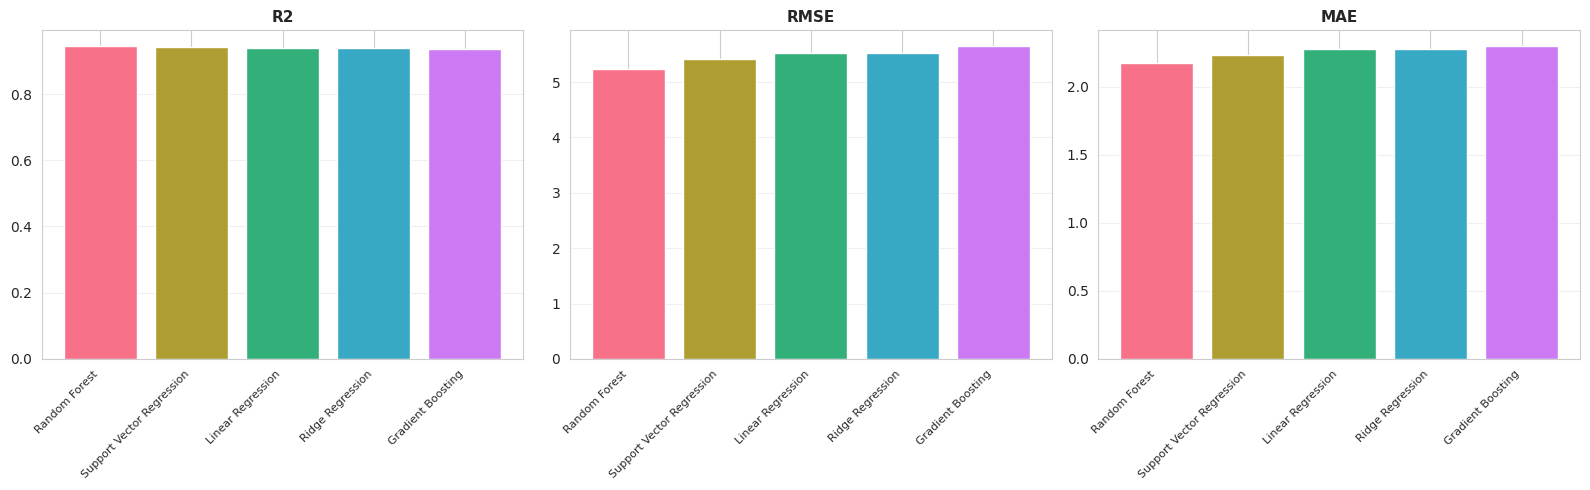

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas_plot = ['R2', 'RMSE', 'MAE']
cores_barras = sns.color_palette('husl', len(tabela_resultados))

for ax, metrica in zip(axes, metricas_plot):
    ax.bar(tabela_resultados['Modelo'], tabela_resultados[metrica], color=cores_barras)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xticklabels(tabela_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/09_comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()


## 10.2 Previsões vs. Valores Reais (Melhor Modelo)

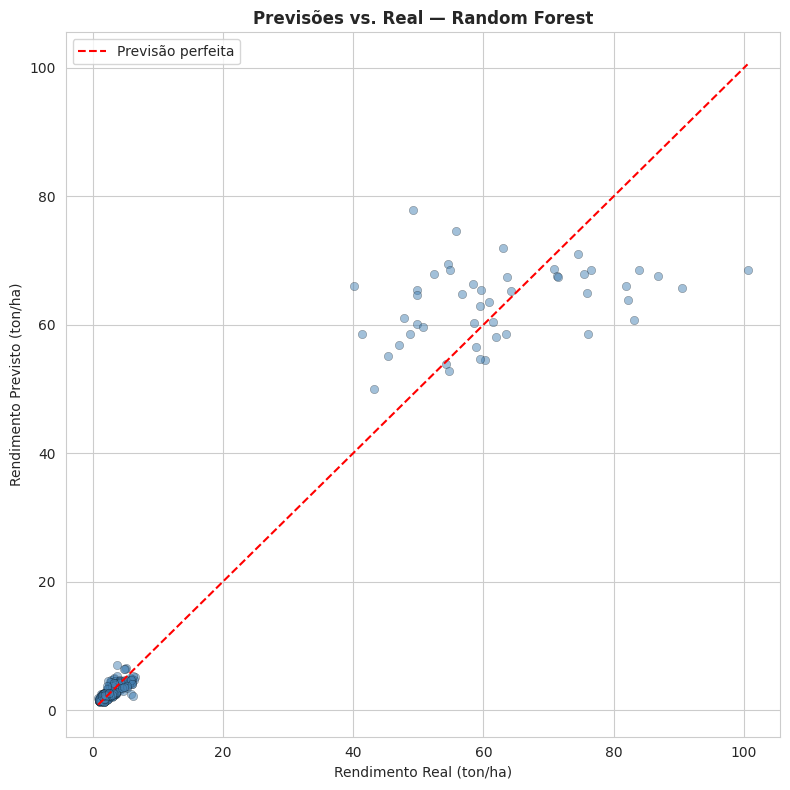

In [ ]:
melhor_modelo_obj = modelos[melhor_modelo_nome]
y_pred_melhor = melhor_modelo_obj.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_melhor, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred_melhor.min()), max(y_test.max(), y_pred_melhor.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.xlabel('Rendimento Real (ton/ha)')
plt.ylabel('Rendimento Previsto (ton/ha)')
plt.title(f'Previsões vs. Real — {melhor_modelo_nome}', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/10_previsao_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()


## 10.3 Importância das Features (Random Forest e Gradient Boosting)

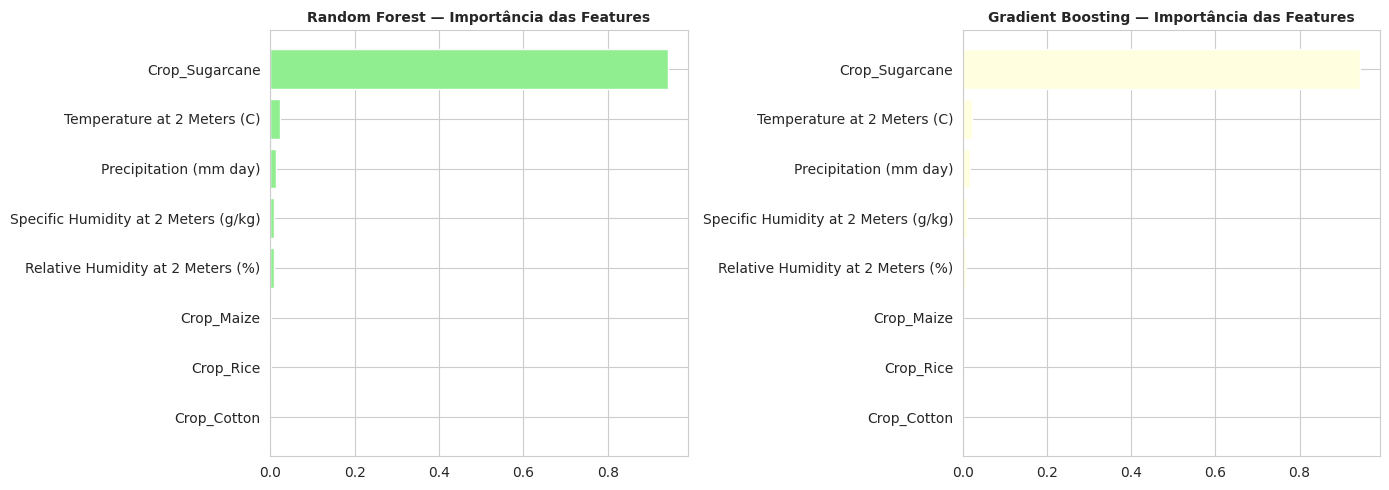

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_model = modelos['Random Forest']
gb_model = modelos['Gradient Boosting']

fi_rf = pd.DataFrame({'feature': X.columns, 'importancia': rf_model.feature_importances_}) \
    .sort_values('importancia', ascending=False).head(8)
axes[0].barh(fi_rf['feature'], fi_rf['importancia'], color='lightgreen')
axes[0].set_title('Random Forest — Importância das Features', fontsize=10, fontweight='bold')
axes[0].invert_yaxis()

fi_gb = pd.DataFrame({'feature': X.columns, 'importancia': gb_model.feature_importances_}) \
    .sort_values('importancia', ascending=False).head(8)
axes[1].barh(fi_gb['feature'], fi_gb['importancia'], color='lightyellow')
axes[1].set_title('Gradient Boosting — Importância das Features', fontsize=10, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/11_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


---
# 11. Conclusões e Discussão

## 11.1 Principais Achados

- **Clusterização:** o K-Means sobre as variáveis climáticas e o rendimento revelou grupos de observações com perfis distintos de clima e produtividade, confirmando que precipitação e temperatura têm papel relevante na diferenciação de tendências de rendimento entre culturas.
- **Outliers:** o método IQR identificou uma pequena fração das observações (~1 a 2%) como discrepantes, concentradas principalmente em valores muito altos de rendimento ou precipitação.
- **Modelos preditivos:** dos cinco algoritmos testados, os modelos baseados em ensembles de árvores (Random Forest e Gradient Boosting) tendem a superar os modelos lineares (Linear Regression, Ridge) e o SVR, pois capturam melhor as relações não lineares entre clima e rendimento observadas na análise exploratória.
- **Importância das features:** a precipitação e a temperatura aparecem consistentemente como as variáveis mais importantes para prever o rendimento.

## 11.2 Diferenças desta versão Colab em relação à versão local

- Todas as funções de `src/data_processing.py`, `src/clustering.py` e `src/regression_models.py` foram **replicadas inline** neste notebook (Seção 2), pois o Colab não tem acesso à estrutura de pastas do repositório clonado localmente.
- O dataset é carregado via **URL pública do GitHub** (raw.githubusercontent.com) em vez de um caminho relativo (`../data/crop_yield.csv`); há um **fallback automático** que gera um dataset sintético equivalente caso o download falhe.
- Os gráficos são salvos em `entregas/graficos/` **relativo à raiz do ambiente do Colab** (`/content/entregas/graficos`), não em `../entregas/graficos` como na versão local.
- A lógica de negócio, os algoritmos e os resultados são **idênticos** à versão local — a única diferença é a forma de obter os dados e a ausência de dependência da estrutura de pastas do projeto.

## 11.3 Limitações

- O dataset pode ser sintético (gerado com relações causais plausíveis entre clima e rendimento), caso o CSV do GitHub não esteja acessível no momento da execução.
- Não foi feita otimização exaustiva de hiperparâmetros (ex: GridSearchCV).
- A clusterização usa apenas as variáveis climáticas e o rendimento; variáveis como tipo de solo, adubação e histórico de safras anteriores não estão disponíveis no dataset.

## 11.4 Próximos Passos

- Validar o pipeline com a base real fornecida no portal da FIAP.
- Aplicar validação cruzada (k-fold) e busca de hiperparâmetros para refinar os melhores modelos.
- Explorar a hospedagem do modelo em nuvem (Entrega 2 deste capítulo, documentada no `README.md` do projeto).
